# FIRMS quickstart — recent active fires

Fetch recent **active-fire detections** (MODIS / VIIRS) from [NASA FIRMS](https://firms.modaps.eosdis.nasa.gov/) through the `earthlens` FIRMS backend, and plot the fire pixels coloured by fire radiative power (FRP).

FIRMS is a `vector` backend: `download()` returns a pyramids `FeatureCollection` (a `geopandas.GeoDataFrame`, CRS `EPSG:4326`), one row per fire pixel.

## Setup

Pull in the imports up front: `EarthLens` is the unified entry point and `matplotlib.pyplot` is used for the final scatter. We also prepare an output directory — FIRMS is a file-writing-plus-in-memory `vector` backend, so `download()` writes the detections to `firms_output/` and returns them as a `GeoDataFrame`.

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
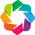

In [1]:
import datetime as dt
import os
from pathlib import Path

import holoviews as hv
import matplotlib.pyplot as plt

from digitalearth.interactive import InteractiveMap
from earthlens.core import EarthLens

# Registers HoloViews' Bokeh notebook hooks. Without it an InteractiveMap has no
# display path and the cell renders nothing at all.
hv.extension('bokeh')

# Off the system drive; override with EARTHLENS_CACHE.
OUT_DIR = Path(os.environ.get('EARTHLENS_CACHE', 'D:/earthlens-cache')) / 'firms'
OUT_DIR.mkdir(parents=True, exist_ok=True)

### Credentials

FIRMS needs a free `MAP_KEY` (https://firms.modaps.eosdis.nasa.gov/api/map_key/). Set `FIRMS_MAP_KEY` in your environment; the live cells below skip cleanly when it is absent, so the notebook never fails offline.

In [2]:
HAS_KEY = bool(os.environ.get('FIRMS_MAP_KEY'))
print('FIRMS_MAP_KEY set:', HAS_KEY)

FIRMS_MAP_KEY set: True


## Query

`variables` is a list of FIRMS **sensor codes** (not data variables). We use the 375 m VIIRS S-NPP near-real-time sensor over Southern California for a recent 7-day window. FIRMS caps requests at 10 days / one sensor, but the backend chunks longer windows transparently.

### Date window

FIRMS near-real-time retains only the most recent ~2 months, so we anchor the window to a recent 7-day span ending today.

In [3]:
TODAY = dt.date.today()
START = (TODAY - dt.timedelta(days=7)).strftime('%Y-%m-%d')
END = TODAY.strftime('%Y-%m-%d')

### Build the request and download

We build the `EarthLens` request first — source, sensor (`variables`), date window, bounding box, and output path — then call `download()` as a separate step. The whole thing stays inside a guard so the notebook skips cleanly when no `MAP_KEY` is set or the live query fails. The result is written to `firms_output/` and returned in memory.

In [4]:
fires = None
if HAS_KEY:
    try:
        request = EarthLens(
            data_source='firms',
            variables=['VIIRS_SNPP_NRT'],
            start=START,
            end=END,
            aoi=[-119.0, 33.0, -117.0, 35.0],
            path=OUT_DIR,
        )
        fires = request.download(progress_bar=False)
        print('detections:', len(fires))
    except Exception as exc:  # keep the notebook safe offline
        print('skipped live query:', exc)

2026-09-09 00:05:01.214 | INFO     | earthlens.firms.backend:_search:335 - FIRMS request: 1 sensor(s) x 2 chunk(s) = 2 CSV GET(s)


2026-09-09 00:05:03.364 | INFO     | earthlens.firms.backend:download:583 - FIRMS download summary: 115 detection(s) written to D:\earthlens-cache\firms\firms_VIIRS_SNPP_NRT_20260902_20260909.gpkg


detections: 115


## Inspect the detections

Every row is one fire pixel with a normalised `confidence_pct` and `frp` (MW).

In [5]:
if fires is not None and len(fires):
    cols = [
        'acq_datetime',
        'sensor',
        'confidence',
        'confidence_pct',
        'brightness_k',
        'frp',
        'daynight',
        'geometry',
    ]
    display(fires[cols].head())
    print('CRS:', fires.crs)

,acq_datetime,sensor,confidence,confidence_pct,brightness_k,frp,daynight,geometry
0,2026-09-02 09:49:00+00:00,VIIRS_SNPP_NRT,n,60.0,303.22,0.56,N,POINT (-117.61877 33.49208)
1,2026-09-02 09:49:00+00:00,VIIRS_SNPP_NRT,n,60.0,310.49,1.08,N,POINT (-117.82249 33.61197)
2,2026-09-02 09:49:00+00:00,VIIRS_SNPP_NRT,n,60.0,304.18,0.69,N,POINT (-117.7111 33.71696)
3,2026-09-02 09:49:00+00:00,VIIRS_SNPP_NRT,n,60.0,308.12,0.40,N,POINT (-118.21551 33.77443)
4,2026-09-02 09:49:00+00:00,VIIRS_SNPP_NRT,n,60.0,309.53,0.87,N,POINT (-118.23627 33.77759)


CRS: EPSG:4326


## Plot the fire pixels coloured by FRP

Plotting the `GeoDataFrame` directly with `column='frp'` colours each detection by its fire radiative power, so the most intense pixels stand out.

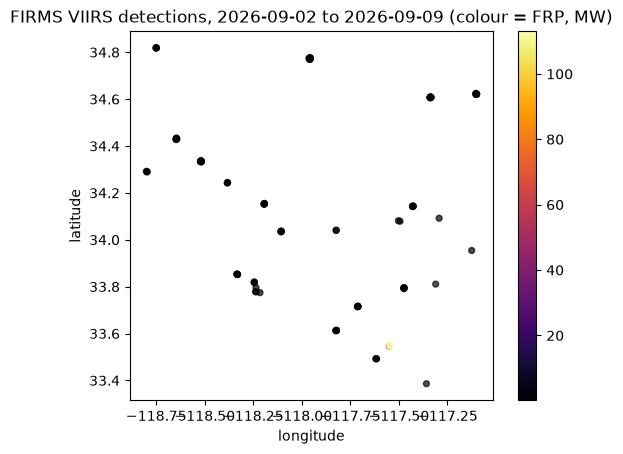

In [6]:
if fires is not None and len(fires):
    ax = fires.plot(column='frp', cmap='inferno', markersize=18, alpha=0.7, legend=True)
    ax.set_title(f'FIRMS VIIRS detections, {START} to {END} (colour = FRP, MW)')
    ax.set_xlabel('longitude')
    ax.set_ylabel('latitude')
    plt.show()

## Inspecting individual detections — Digital-Earth's interactive tier

The scatter above answers "where were the fires"; it cannot answer "what is *that* one". Every detection
carries a brightness, a confidence, an FRP and an acquisition time, and a static PNG shows none of them.

`digitalearth.interactive.InteractiveMap` renders the same points through HoloViz over an XYZ basemap, so
the map pans and zooms and `hover` puts each detection's own attributes under the cursor. The `rasterize`
threshold means this keeps working when a query returns hundreds of thousands of detections instead of a
few hundred — past the threshold the points are aggregated server-side into an image rather than shipped to
the browser individually.

In [7]:
if fires is not None and len(fires):
    fire_map = (
        InteractiveMap(width=860, height=560)
        .tiles('CartoDark')
        .points(fires, value_column='frp', cmap='inferno', size=7)
        .hover(tooltips=[
            ('acquired', '@acq_datetime{%F %H:%M}'),
            ('FRP (MW)', '@frp{0.0}'),
            ('brightness (K)', '@brightness_k{0.0}'),
            ('confidence', '@confidence'),
            ('day/night', '@daynight'),
        ], formatters={'@acq_datetime': 'datetime'})
        .colorbar()
    )
    # Also written as a standalone page, for sending to someone without the notebook.
    print('standalone copy:', fire_map.save(str(OUT_DIR / 'firms_detections.html')))

standalone copy: D:\earthlens-cache\firms\firms_detections.html


In [8]:
# Pan, zoom, and hover any detection to read its own acquisition time, FRP,
# brightness and confidence. The last expression is the map, so HoloViews renders
# it here rather than it being a picture of a map.
fire_map if fires is not None and len(fires) else 'no detections to map'